In [2]:
import os

print(os.listdir("/content"))

['.config', 'Project9_smart-city-traffic-patterns.zip', 'sample_data']


In [3]:
import zipfile
import os

zip_path = "/content/Project9_smart-city-traffic-patterns.zip"
extract_path = "/content/Project9_Dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Outer ZIP Extracted!")
print(os.listdir(extract_path))

✅ Outer ZIP Extracted!
['Project9_smart-city-traffic-patterns']


In [4]:
import os

for root, dirs, files in os.walk("/content/Project9_Dataset"):
    print(f"\n📂 {root}")
    for file in files:
        print("   📄", file)


📂 /content/Project9_Dataset

📂 /content/Project9_Dataset/Project9_smart-city-traffic-patterns
   📄 Project9_smart-city-traffic-patterns.docx
   📄 Project9_smart-city-traffic-patterns.zip


In [5]:
import zipfile
import os

zip_path = "/content/Project9_Dataset/Project9_smart-city-traffic-patterns/Project9_smart-city-traffic-patterns.zip"
extract_path = "/content/Traffic_Project9"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Inner ZIP Extracted Successfully!")

for root, dirs, files in os.walk(extract_path):
    print(f"\n📂 {root}")
    for file in files:
        print("   📄", file)

✅ Inner ZIP Extracted Successfully!

📂 /content/Traffic_Project9

📂 /content/Traffic_Project9/smart-city-traffic-patterns
   📄 datasets_8494_11879_test_BdBKkAj.csv
   📄 train_aWnotuB.csv


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
train = pd.read_csv("/content/Traffic_Project9/smart-city-traffic-patterns/train_aWnotuB.csv")
test = pd.read_csv("/content/Traffic_Project9/smart-city-traffic-patterns/datasets_8494_11879_test_BdBKkAj.csv")

print("Train Shape :", train.shape)
print("Test Shape  :", test.shape)

train.head()

Train Shape : (48120, 4)
Test Shape  : (11808, 3)


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [9]:
train.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [10]:
train.isnull().sum()

,0
DateTime,0
Junction,0
Vehicles,0
ID,0


In [11]:
train['DateTime'] = pd.to_datetime(train['DateTime'])
test['DateTime'] = pd.to_datetime(test['DateTime'])

train.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [12]:
train['Year'] = train['DateTime'].dt.year
train['Month'] = train['DateTime'].dt.month
train['Day'] = train['DateTime'].dt.day
train['Hour'] = train['DateTime'].dt.hour
train['DayOfWeek'] = train['DateTime'].dt.dayofweek

train.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6


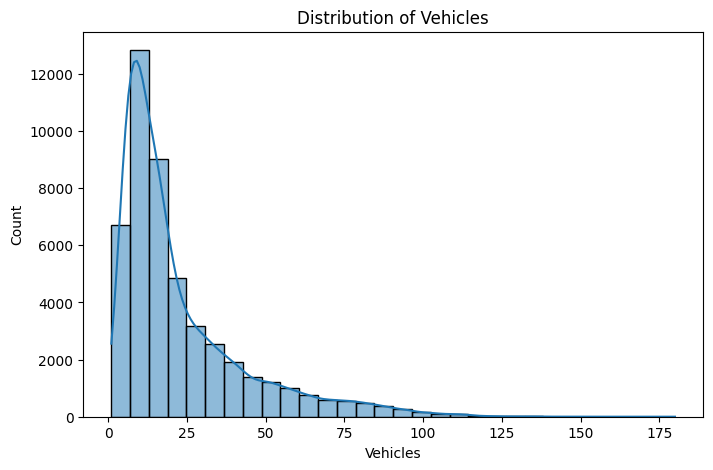

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(train['Vehicles'], bins=30, kde=True)

plt.title("Distribution of Vehicles")

plt.show()

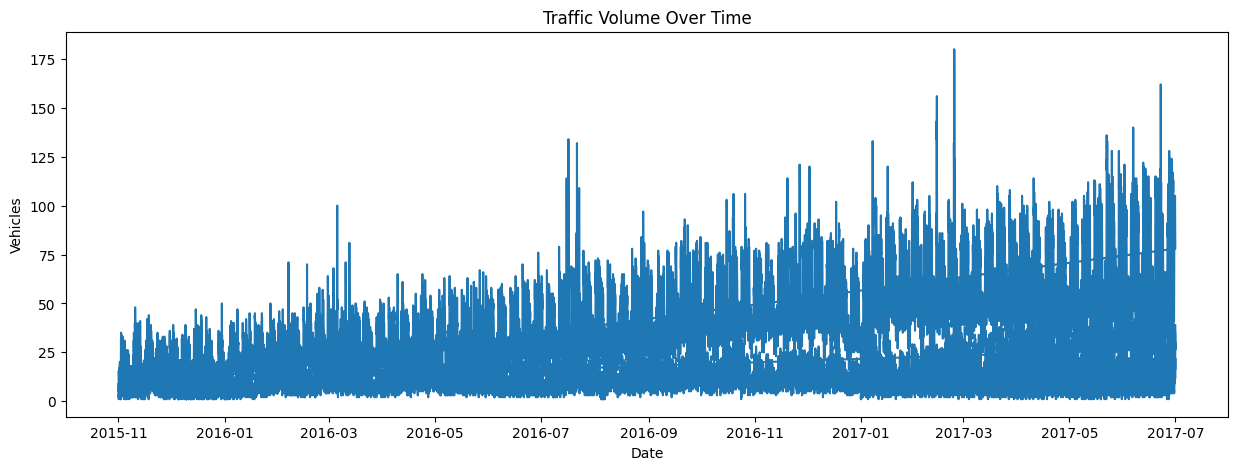

In [15]:
import os

os.makedirs("images", exist_ok=True)

plt.figure(figsize=(15,5))
plt.plot(train['DateTime'], train['Vehicles'])
plt.title("Traffic Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Vehicles")
plt.savefig("images/traffic_over_time.png")
plt.show()

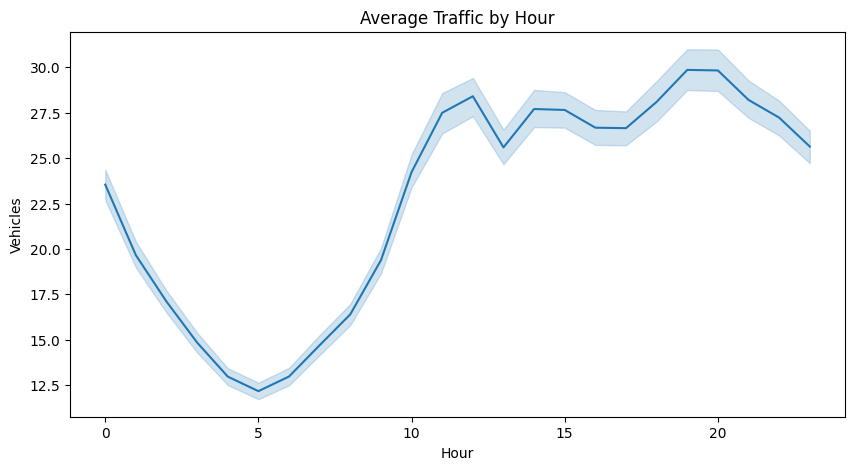

In [16]:
plt.figure(figsize=(10,5))

sns.lineplot(x='Hour', y='Vehicles', data=train)

plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Vehicles")

plt.savefig("images/traffic_by_hour.png")
plt.show()

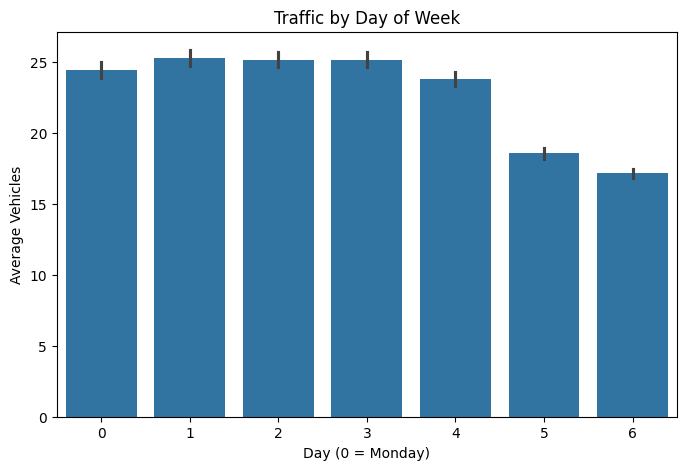

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(x='DayOfWeek', y='Vehicles', data=train)

plt.title("Traffic by Day of Week")
plt.xlabel("Day (0 = Monday)")
plt.ylabel("Average Vehicles")

plt.savefig("images/traffic_by_day.png")
plt.show()

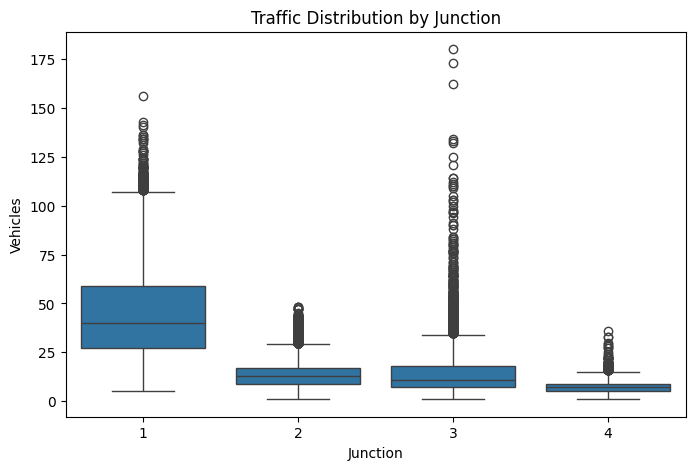

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Junction', y='Vehicles', data=train)

plt.title("Traffic Distribution by Junction")

plt.savefig("images/traffic_by_junction.png")
plt.show()

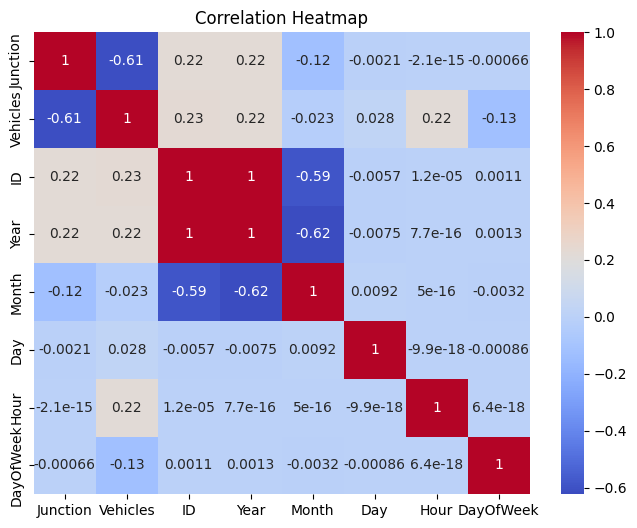

In [19]:
plt.figure(figsize=(8,6))

numeric_train = train.select_dtypes(include=['number'])

sns.heatmap(numeric_train.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png")
plt.show()

In [21]:
X = train[['Junction', 'Year', 'Month', 'Day', 'Hour', 'DayOfWeek']]
y = train['Vehicles']

In [22]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [23]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [24]:
predictions = model.predict(X_valid)

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_valid, predictions)
mse = mean_squared_error(y_valid, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 2.3966500415627596
MSE : 12.649128969243558
RMSE: 3.5565613968050034
R2 Score: 0.9689627529667615


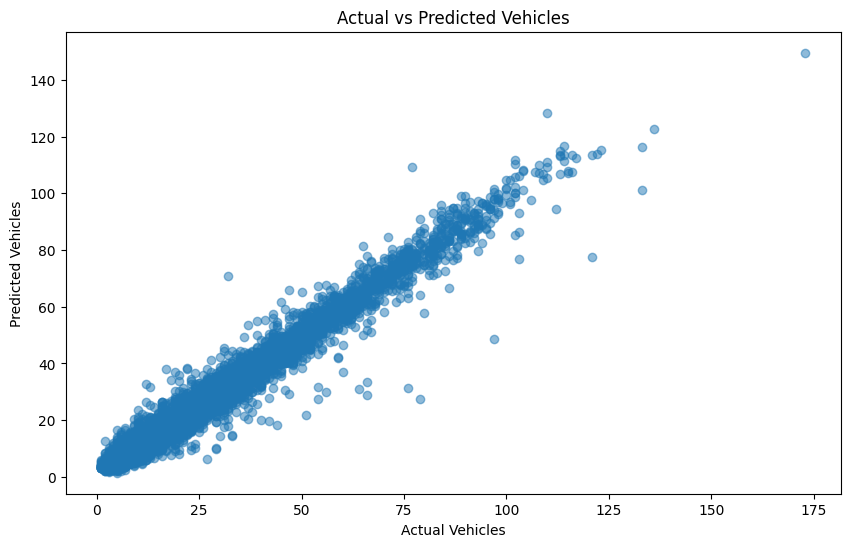

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(y_valid, predictions, alpha=0.5)

plt.xlabel("Actual Vehicles")
plt.ylabel("Predicted Vehicles")
plt.title("Actual vs Predicted Vehicles")

plt.savefig("images/actual_vs_predicted.png")
plt.show()

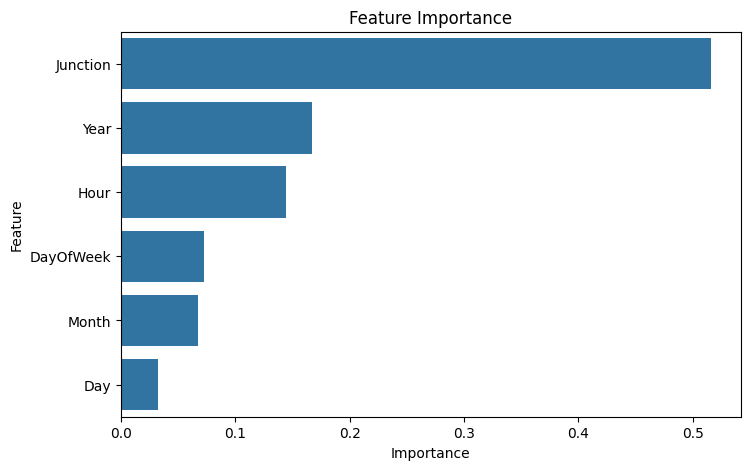

In [27]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))

sns.barplot(data=importance, x="Importance", y="Feature")

plt.title("Feature Importance")

plt.savefig("images/feature_importance.png")
plt.show()

In [28]:
import joblib

joblib.dump(model, "traffic_prediction_model.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!
